In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
fo.list_datasets()

['FLPLAN',
 'UM_teste',
 'WPonly_1024ov224',
 'flplan200',
 'flplanpatches',
 'nc765',
 'nc765_T1024ov224',
 'nc765_T2048ov224',
 'tiles2048_merged',
 'tiles_merged',
 'tiles_merged_2048',
 'train_nc_wp_T1024ov224',
 'umflplan_T1024ov224',
 'umflplan_T2048ov224',
 'wp125',
 'wp125_T1024ov224',
 'wp125_T2048ov224',
 'wp_final_test']

In [3]:
dataset = fo.load_dataset("wp_final_test")

# Baseline Evaluation

In [17]:
import json 

def center_to_topleft(box):
    """
    Converts a normalized bounding box from
    [cx, cy, w, h] -> [x, y, w, h]
    """
    cx, cy, w, h = box

    x = max(0.0, cx - w / 2)
    y = max(0.0, cy - h / 2)

    # Clip width/height so boxes stay inside the image
    w = min(w, 1.0 - x)
    h = min(h, 1.0 - y)

    return [x, y, w, h]


def load_predictions_from_json(
    dataset,
    json_path,
    pred_field="predictions",
    overwrite=True,
):
    """
    Loads RT-DETR predictions from a JSON file into a FiftyOne dataset.

    Parameters
    ----------
    dataset : fo.Dataset or fo.DatasetView
        Dataset containing the tile images.

    json_path : str
        Path to the prediction JSON.

    pred_field : str
        Name of the field where predictions will be stored.

    overwrite : bool
        Whether to overwrite existing predictions.
    """

    with open(json_path, "r") as f:
        predictions = json.load(f)

    # Build lookup by filepath
    pred_lookup = {
        p["filepath"]: p
        for p in predictions
    }

    loaded = 0
    missing = 0

    with dataset.save_context() as context:

        for sample in dataset:

            pred = pred_lookup.get(sample.filepath)

            if pred is None:
                missing += 1
                continue

            if (
                not overwrite
                and sample.get(pred_field, None) is not None
            ):
                continue

            detections = []

            for det in pred["detections"]:

                detections.append(
                    fo.Detection(
                        label=det["label"],
                        bounding_box=center_to_topleft(
                            det["bounding_box"]
                        ),
                        confidence=det.get("confidence"),
                    )
                )

            sample[pred_field] = fo.Detections(
                detections=detections
            )

            context.save(sample)
            loaded += 1

    print(f"Loaded predictions for {loaded} samples.")
    print(f"Skipped {missing} samples with no matching filepath.")

In [18]:
load_predictions_from_json(
    dataset,
    "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/baseline_inference/baseline_test_1_test_predictions.json",
    pred_field="baseline_test1",
)

Loaded predictions for 96 samples.
Skipped 380 samples with no matching filepath.


In [45]:
load_predictions_from_json(
    dataset,
    "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/baseline_inference/baseline_test_3_test_predictions.json",
    pred_field="baseline_test3",
)

load_predictions_from_json(
    dataset,
    "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/models_run/baseline_inference/baseline_test_2_test_predictions.json",
    pred_field="baseline_test2",
)

Loaded predictions for 90 samples.
Skipped 386 samples with no matching filepath.
Loaded predictions for 88 samples.
Skipped 388 samples with no matching filepath.


In [13]:
session = fo.launch_app(dataset, auto=False, port=5151)


Could not connect session, trying again in 10 seconds

Session launched. Run `session.show()` to open the App in a cell output.


In [19]:
session.refresh

<bound method Session.refresh of Dataset:          wp_final_test
Media type:       image
Num samples:      96
Selected samples: 0
Selected labels:  0
Sample:           6a33d1a619d8f6f6ef569371
Session URL:      http://localhost:5151/
View stages:
    1. MatchTags(tags=['test_1'], bool=True, all=False)>

In [14]:
test1_view = dataset.match_tags("test_1")

session.view = test1_view


In [6]:
dataset

Name:        wp_final_test
Media type:  image
Num samples: 476
Persistent:  True
Tags:        []
Sample fields:
    id:                  fiftyone.core.fields.ObjectIdField
    filepath:            fiftyone.core.fields.StringField
    tags:                fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:            fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:          fiftyone.core.fields.DateTimeField
    last_modified_at:    fiftyone.core.fields.DateTimeField
    type_label:          fiftyone.core.fields.StringField
    ground_truth:        fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    region:              fiftyone.core.fields.StringField
    mission_name:        fiftyone.core.fields.StringField
    parent_name:         fiftyone.core.fields.StringField
    gt_field:            fiftyone.core.fields.StringField
    min_area_ratio:      fiftyone.core.fields.FloatField
    n_

In [37]:
test1_view = dataset.match_tags("test_1")

# calculate metrics 
results = test1_view.evaluate_detections(
    "baseline_test1",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_test1",
    iou=0.5,
    compute_mAP=True,
)

Evaluating detections...
 100% |███████████████████| 96/96 [534.2ms elapsed, 0s remaining, 179.7 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 96/96 [576.3ms elapsed, 0s remaining, 166.6 samples/s]      


In [46]:
test2_view = dataset.match_tags("test_2")
test3_view = dataset.match_tags("test_3")

# calculate metrics 
results2 = test2_view.evaluate_detections(
    "baseline_test2",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_test2",
    iou=0.5,
    compute_mAP=True,
)

results3 = test3_view.evaluate_detections(
    "baseline_test3",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_test3",
    iou=0.5,
    compute_mAP=True,
)

Evaluating detections...
 100% |███████████████████| 88/88 [479.4ms elapsed, 0s remaining, 183.6 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 88/88 [503.6ms elapsed, 0s remaining, 174.8 samples/s]      
Evaluating detections...
 100% |███████████████████| 90/90 [560.7ms elapsed, 0s remaining, 160.5 samples/s]      
Performing IoU sweep...
 100% |███████████████████| 90/90 [524.5ms elapsed, 0s remaining, 171.6 samples/s]      


In [ ]:
test1_view = dataset.match_tags("test_1")

# calculate metrics 
results = test1_view.evaluate_detections(
    "baseline_test1",
    gt_field="ground_truth",
    method="coco",
    eval_key="eval_test1",
    iou=0.5,
    compute_mAP=True,
)

### compute the baseline metrics and save in a parquet

In [48]:
import numpy as np 


def _ap_from_pr(recall, precision):
    """All-points AP (area under P-R curve). Single-class -> mAP@iou."""
    r = np.asarray(recall, dtype=float)
    p = np.asarray(precision, dtype=float)
    order = np.argsort(r)
    r, p = r[order], p[order]
    mrec = np.concatenate([[0.0], r, [1.0]])
    mpre = np.concatenate([[p[0] if len(p) else 0.0], p, [0.0]])
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1]))

    
def _sweep_metrics(res, iou=0.5, n_thresholds=200):
    """
    Confidence sweep at a fixed IoU over a COCODetectionResults object.
    Returns the F1-optimal operating point plus AP@iou / max-recall@iou.
    Positive labels inferred from res.ytrue (handles 'dugong' + 'calf').
    """
    ytrue = np.array(res.ytrue)
    ypred = np.array(res.ypred)
    confs = np.array([v if v is not None else 0.0 for v in res.confs], dtype=float)
    ious  = np.array([v if v is not None else 0.0 for v in res.ious],  dtype=float)

    pos = set(np.unique(ytrue)) - {"(none)"}
    is_pos = lambda a: np.isin(a, list(pos))

    n_gt = int((ypred == "(none)").sum() + (is_pos(ytrue) & is_pos(ypred)).sum())
    pred_mask = ypred != "(none)"

    ts = np.linspace(0.01, 0.99, n_thresholds)
    P = np.zeros(n_thresholds); R = np.zeros(n_thresholds); F = np.zeros(n_thresholds)
    TP = np.zeros(n_thresholds, int); FP = np.zeros(n_thresholds, int); FN = np.zeros(n_thresholds, int)

    for i, t in enumerate(ts):
        mask = pred_mask & (confs >= t)
        tp = int((is_pos(ytrue[mask]) & (ious[mask] >= iou)).sum())
        fp = int((ytrue[mask] == "(none)").sum())
        fn = n_gt - tp
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        P[i], R[i] = prec, rec
        F[i] = 2 * prec * rec / (prec + rec + 1e-9)
        TP[i], FP[i], FN[i] = tp, fp, fn

    b = int(np.argmax(F))
    return {
        "n_gt": n_gt,
        "positive_label": str(sorted(pos)),
        "mAP_50": _ap_from_pr(R, P),
        "mAR_50": float(R.max()),
        "f1_threshold": float(ts[b]),
        "f1": float(F[b]),
        "precision": float(P[b]),
        "recall": float(R[b]),
        "tp": int(TP[b]), "fp": int(FP[b]), "fn": int(FN[b]),
    }

In [50]:
del list 

In [51]:
m1 = _sweep_metrics(results, iou=0.5, n_thresholds=200)
m2 = _sweep_metrics(results2, iou=0.5, n_thresholds=200)
m3 = _sweep_metrics(results3, iou=0.5, n_thresholds=200)

In [52]:
import pandas as pd 
baseline_rows = []
for seed, res, m in [(1, results, m1), (2, results2, m2), (3, results3, m3)]:
    baseline_rows.append({
        "method": "baseline", "partition": 1.0, "partition_pct": 100, "seed": seed,
        "pred_field": f"baseline_test{seed}",
        "mAP_50": m["mAP_50"], "mAP_50_95": float(res.mAP()),
        "mAR": float(res.mAR()), "mAR_50": m["mAR_50"],
        "f1": m["f1"], "precision": m["precision"], "recall": m["recall"],
        "f1_threshold": m["f1_threshold"], "tp": m["tp"], "fp": m["fp"], "fn": m["fn"],
        "n_gt": m["n_gt"], "iou": 0.5, "positive_label": m["positive_label"], "status": "ok",
    })
baseline_df = pd.DataFrame(baseline_rows)
# df = pd.concat([df, pd.DataFrame(baseline_rows)], ignore_index=True)

In [53]:
baseline_df

,method,partition,partition_pct,seed,pred_field,mAP_50,mAP_50_95,mAR,mAR_50,f1,precision,recall,f1_threshold,tp,fp,fn,n_gt,iou,positive_label,status
0,baseline,1.0,100,1,baseline_test1,0.569191,0.372370,0.450000,0.640845,0.649573,0.826087,0.535211,0.088794,76,16,66,142,0.5,[np.str_('dugong')],ok
1,baseline,1.0,100,2,baseline_test2,0.634092,0.367137,0.497345,0.734513,0.702970,0.797753,0.628319,0.093719,71,18,42,113,0.5,[np.str_('dugong')],ok
2,baseline,1.0,100,3,baseline_test3,0.633252,0.458222,0.579630,0.768519,0.670270,0.805195,0.574074,0.098643,62,15,46,108,0.5,[np.str_('dugong')],ok


In [54]:
import os 
baseline_df.to_parquet('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/results_df/baseline_all_seeds.parquet')

In [36]:
dataset.delete_evaluations()

In [ ]:
dataset.delete_sample_field("baseline_test1")

In [35]:
dataset.first()['ground_truth']['detections']

[<Detection: {
     'id': '6a33d1a219d8f6f6ef569258',
     'attributes': {},
     'tags': [],
     'label': 'dugong',
     'bounding_box': [0.5234375, 0.123046875, 0.06640625, 0.12109375],
     'mask': None,
     'mask_path': None,
     'confidence': None,
     'index': None,
 }>]

In [34]:
for sample in dataset.iter_samples(progress=True):
    list = sample['ground_truth']['detections']
    for ele in list:
        ele['label'] = 'dugong'
    sample.save()

 100% |█████████████████| 476/476 [1.4s elapsed, 0s remaining, 315.5 samples/s]         


In [38]:
results.print_metrics()

accuracy   0.25
precision  0.3
recall     0.64
fscore     0.41
support    142


# Compute df

In [43]:
from importlib import reload

In [44]:
import evaluate
reload(evaluate)

<module 'evaluate' from '/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/src/evaluate.py'>

In [41]:
import sys
sys.path.append("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/src")

# Restart kernel first, then:
from evaluate import sweep_thresholds, plot_sweep, extract_all_metrics

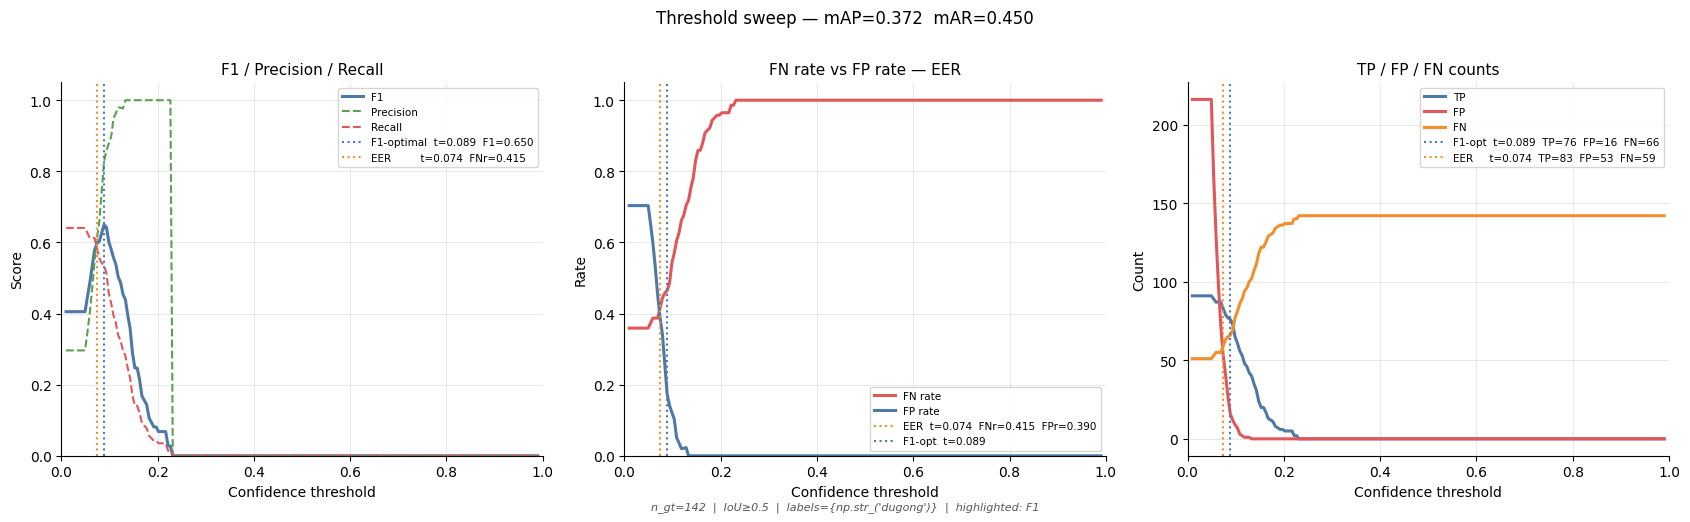

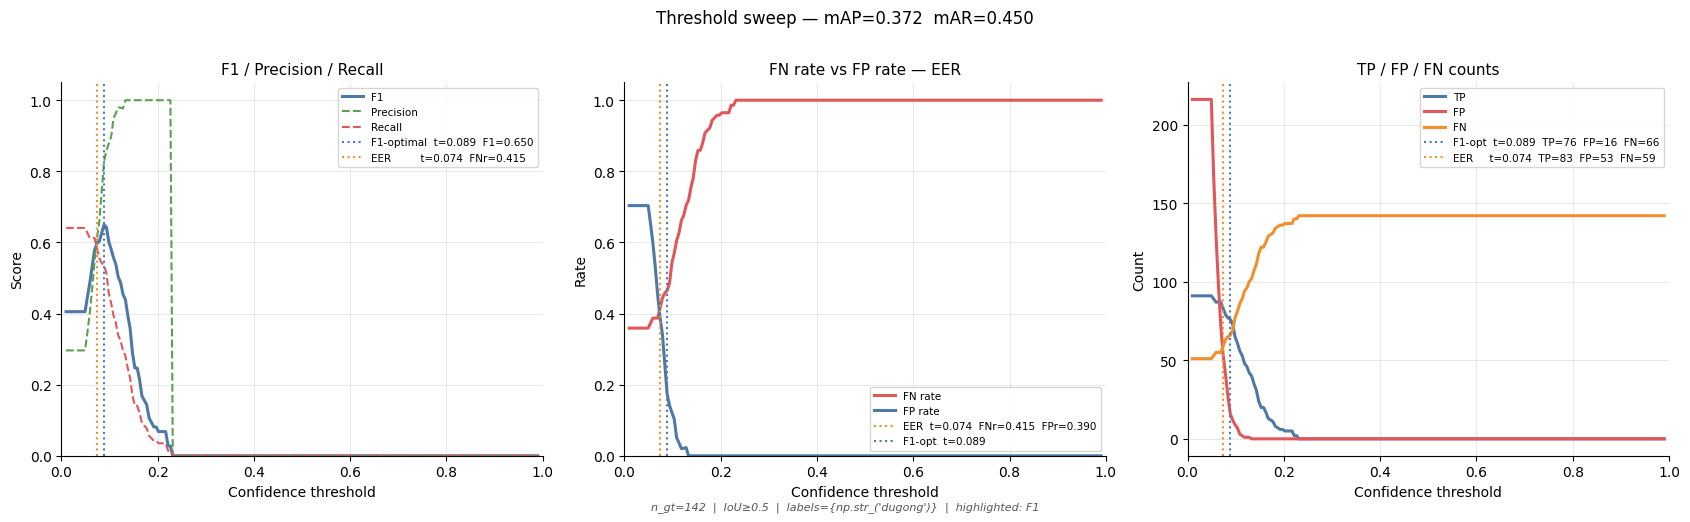

In [42]:
# plot the sweep
plot_sweep(results, method='f1')

In [ ]:
df_seed = extract_all_metrics(
    results_dict = results,
    seed         = 2,
    method       = "f1",       # or "f1" — chosen after inspecting plot_sweep above
    # iou_thresh = None         # reads from res.config.iou automatically
)